<a href="https://colab.research.google.com/github/2303a51355/High-performance-computing/blob/main/HPC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Smart Traffic Signal Timing Optimizer

In [2]:
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor
from IPython.display import display, HTML

In [3]:
display(HTML("""
<div style='background:linear-gradient(90deg,#0ea5e9,#1e3a8a);
padding:30px;border-radius:15px;color:white;text-align:center'>
<h1>🚦 Smart Traffic Signal Timing Optimizer</h1>
<h3>High Performance Computing Project</h3>
<p>Serial vs Parallel Processing for Smart City Traffic</p>
</div>
"""))

In [4]:
NUM_JUNCTIONS = 20
MAX_CARS = 100
CYCLE_TIME = 120

In [5]:
def optimize_signal(j):

    ns = j["north"] + j["south"]
    ew = j["east"] + j["west"]
    total = ns + ew

    green_ns = (ns / total) * CYCLE_TIME
    green_ew = (ew / total) * CYCLE_TIME

    wait_before = total * 0.60
    wait_after = abs(ns-ew)*0.20 + total*0.25

    correct = 1 if (green_ns >= green_ew and ns >= ew) or (green_ew > green_ns and ew > ns) else 0

    return {
        "ID": j["id"],
        "NS Cars": ns,
        "EW Cars": ew,
        "Green NS": round(green_ns,2),
        "Green EW": round(green_ew,2),
        "Wait Before": round(wait_before,2),
        "Wait After": round(wait_after,2),
        "Saved": round(wait_before-wait_after,2),
        "Correct": correct
    }

In [6]:
traffic = []

for i in range(NUM_JUNCTIONS):
    traffic.append({
        "id": i+1,
        "north": random.randint(10,MAX_CARS),
        "south": random.randint(10,MAX_CARS),
        "east": random.randint(10,MAX_CARS),
        "west": random.randint(10,MAX_CARS)
    })

# SERIAL
t1 = time.time()
serial_results = [optimize_signal(x) for x in traffic]
serial_time = time.time() - t1

# PARALLEL
t2 = time.time()

with ThreadPoolExecutor() as executor:
    parallel_results = list(executor.map(optimize_signal, traffic))

parallel_time = time.time() - t2

In [7]:
accuracy = sum(x["Correct"] for x in parallel_results)/NUM_JUNCTIONS*100

before = np.mean([x["Wait Before"] for x in parallel_results])
after  = np.mean([x["Wait After"] for x in parallel_results])

speedup = serial_time/parallel_time if parallel_time>0 else 0
improve = ((before-after)/before)*100

In [8]:
display(HTML(f"""
<div style='display:grid;grid-template-columns:repeat(4,1fr);gap:15px;'>

<div style='background:#1e293b;color:white;padding:20px;border-radius:12px;text-align:center'>
<h3>Serial Time</h3><h2>{serial_time:.4f}s</h2></div>

<div style='background:#1e293b;color:white;padding:20px;border-radius:12px;text-align:center'>
<h3>Parallel Time</h3><h2>{parallel_time:.4f}s</h2></div>

<div style='background:#1e293b;color:white;padding:20px;border-radius:12px;text-align:center'>
<h3>Speedup</h3><h2>{speedup:.2f}x</h2></div>

<div style='background:#1e293b;color:white;padding:20px;border-radius:12px;text-align:center'>
<h3>Accuracy</h3><h2>{accuracy:.2f}%</h2></div>

</div>
"""))

In [9]:
df = pd.DataFrame(parallel_results)
df.head(10)

,ID,NS Cars,EW Cars,Green NS,Green EW,Wait Before,Wait After,Saved,Correct
0,1,56,154,32.00,88.00,126.0,72.10,53.90,1
1,2,157,42,94.67,25.33,119.4,72.75,46.65,1
2,3,159,90,76.63,43.37,149.4,76.05,73.35,1
3,4,165,123,68.75,51.25,172.8,80.40,92.40,1
4,5,75,74,60.40,59.60,89.4,37.45,51.95,1
5,6,143,123,64.51,55.49,159.6,70.50,89.10,1
6,7,96,190,40.28,79.72,171.6,90.30,81.30,1
7,8,97,74,68.07,51.93,102.6,47.35,55.25,1
8,9,156,148,61.58,58.42,182.4,77.60,104.80,1
9,10,92,129,49.95,70.05,132.6,62.65,69.95,1


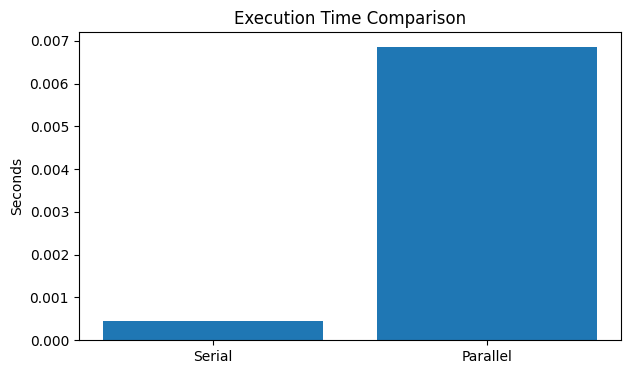

In [10]:
plt.figure(figsize=(7,4))
plt.bar(["Serial","Parallel"], [serial_time,parallel_time])
plt.title("Execution Time Comparison")
plt.ylabel("Seconds")
plt.show()

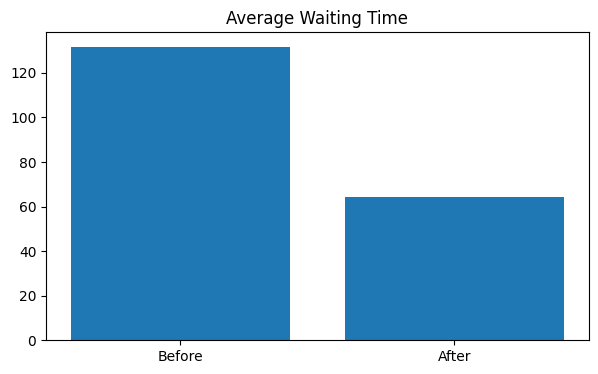

In [11]:
plt.figure(figsize=(7,4))
plt.bar(["Before","After"], [before,after])
plt.title("Average Waiting Time")
plt.show()

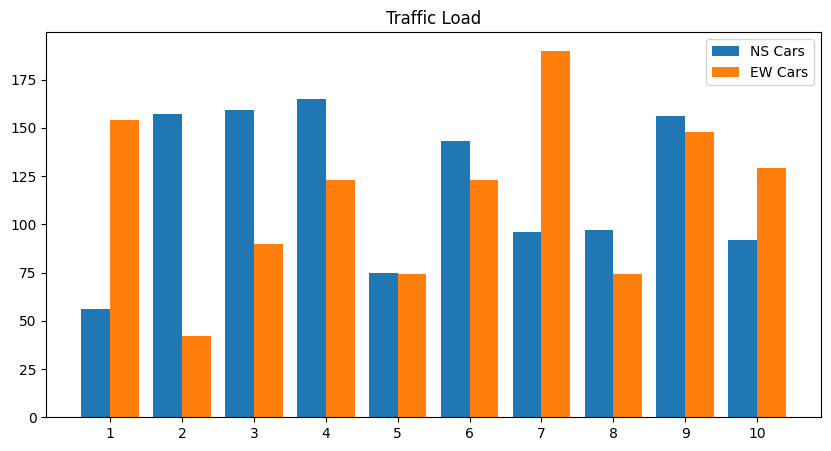

In [12]:
first10 = df.head(10)
x = np.arange(len(first10))

plt.figure(figsize=(10,5))
plt.bar(x-0.2, first10["NS Cars"], width=0.4, label="NS Cars")
plt.bar(x+0.2, first10["EW Cars"], width=0.4, label="EW Cars")
plt.xticks(x, first10["ID"])
plt.title("Traffic Load")
plt.legend()
plt.show()

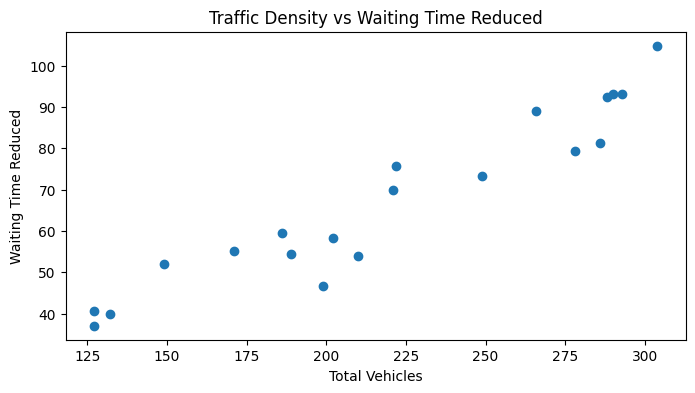

In [15]:
total = df["NS Cars"] + df["EW Cars"]

plt.figure(figsize=(8,4))
plt.scatter(total, df["Saved"])
plt.title("Traffic Density vs Waiting Time Reduced")
plt.xlabel("Total Vehicles")
plt.ylabel("Waiting Time Reduced")
plt.show()

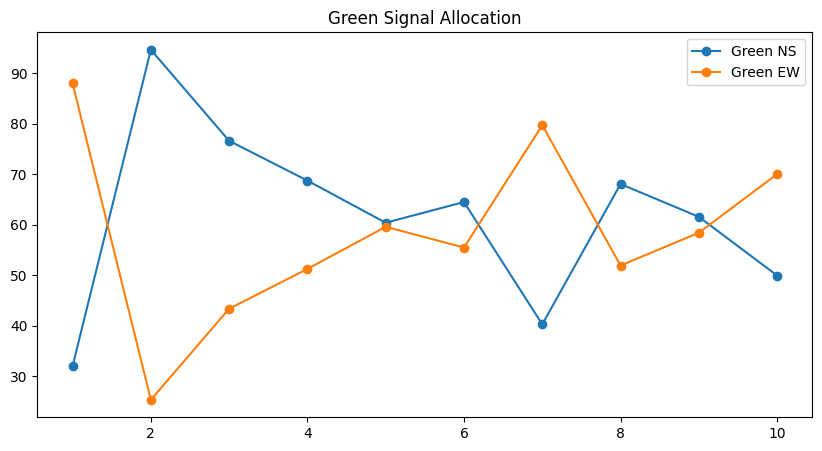

In [13]:
plt.figure(figsize=(10,5))
plt.plot(first10["ID"], first10["Green NS"], marker='o', label="Green NS")
plt.plot(first10["ID"], first10["Green EW"], marker='o', label="Green EW")
plt.title("Green Signal Allocation")
plt.legend()
plt.show()